# **Restaurant Cuisine Analysis**


1. Which cuisine has the highest budget? <br>
2. Which cuisine has the lowest budget? <br>
3. How many males consume alcohol socially? <br>
4. Which gender consume alcohol "Often" more frequently? <br>
5. Is the budget for French cuisine higher than for Indian cuisine? <br>
6. Which cuisine should be promoted to make higher revenue?

### **Import Libraries and Dataset and getting informations on the dataset**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt    #Imported libraries for Data analysis and Visualization

In [2]:
import os
print(os.getcwd())    #printing current working directory

c:\Users\u\OneDrive\Desktop\PROJECT\Restaurant PROJECT EDA


In [3]:
df=pd.read_csv(r"C:\Users\u\OneDrive\Desktop\PROJECT\Restaurant PROJECT EDA\Cuisine_rating.csv")

### **Data Loading and Inspection**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   User ID         200 non-null    int64  
 1   Area code       200 non-null    int64  
 2   Location        200 non-null    object 
 3   Gender          200 non-null    object 
 4   YOB             200 non-null    int64  
 5   Marital Status  200 non-null    object 
 6   Activity        200 non-null    object 
 7   Budget          200 non-null    int64  
 8   Cuisines        200 non-null    object 
 9   Alcohol         200 non-null    object 
 10  Smoker          200 non-null    object 
 11  Food Rating     200 non-null    int64  
 12  Service Rating  200 non-null    int64  
 13  Overall Rating  200 non-null    float64
 14  Often A S       200 non-null    object 
dtypes: float64(1), int64(6), object(8)
memory usage: 23.6+ KB


In [5]:
df.isna().sum()

User ID           0
Area code         0
Location          0
Gender            0
YOB               0
Marital Status    0
Activity          0
Budget            0
Cuisines          0
Alcohol           0
Smoker            0
Food Rating       0
Service Rating    0
Overall Rating    0
Often A S         0
dtype: int64

In [6]:
df.isnull().sum()

User ID           0
Area code         0
Location          0
Gender            0
YOB               0
Marital Status    0
Activity          0
Budget            0
Cuisines          0
Alcohol           0
Smoker            0
Food Rating       0
Service Rating    0
Overall Rating    0
Often A S         0
dtype: int64

##### *Here, it indicates there are no null values in the Dataset*

In [7]:
df.describe()     

,User ID,Area code,YOB,Budget,Food Rating,Service Rating,Overall Rating
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,141.060000,1984.830000,3.815000,3.220000,3.230000,3.225000
std,57.879185,26.130257,16.809339,1.056578,1.411226,1.526022,1.079445
min,1.000000,101.000000,1955.000000,1.000000,1.000000,1.000000,1.000000
25%,50.750000,123.000000,1971.000000,3.000000,2.000000,2.000000,2.500000
50%,100.500000,135.000000,1987.000000,4.000000,3.000000,3.000000,3.000000
75%,150.250000,158.000000,2000.000000,5.000000,5.000000,5.000000,4.000000
max,200.000000,199.000000,2009.000000,5.000000,5.000000,5.000000,5.000000


##### *describe fn shows summary statistics for numerical columns in the dataset*

In [8]:
df.head()

,User ID,Area code,Location,Gender,YOB,Marital Status,Activity,Budget,Cuisines,Alcohol,Smoker,Food Rating,Service Rating,Overall Rating,Often A S
0,1,153,"Upper East Side,NY",Female,2006,Single,Professional,3,Japanese,Never,Never,5,4,4.5,No
1,2,123,"St. George,NY",Female,1991,Married,Student,3,Indian,Never,Socially,1,1,1.0,No
2,3,122,"Upper West Side,NY",Male,1977,Single,Student,5,Seafood,Often,Often,5,5,5.0,Yes
3,4,153,"Upper East Side,NY",Female,1956,Married,Professional,5,Japanese,Never,Socially,3,1,2.0,No
4,5,129,"Central Park,NY",Male,1997,Single,Student,4,Filipino,Socially,Never,2,4,3.0,No


##### *head displays the first few rows of the DataFrame*

In [9]:
df.shape

(200, 15)

## **Get information about cuisines and budget**

In [10]:
cuisine_budget=df.groupby(["Cuisines"])["Budget"].sum()
cuisine_budget

Cuisines
Chinese      98
Filipino    126
French      134
Indian      109
Italian      70
Japanese    148
Seafood      78
Name: Budget, dtype: int64

##### *Knowing that Japanese cuisine has the highest budget sum(148) and Italian has the lowest(70) can help the restaurant allocate resourses effectively.They might prioritize or promote Japanese cuisine given its higher budget implication, or optimize menu pricing and offerings based on budget trends.*

## **Represent alcohol consumption by male and female using groupby fn**

In [11]:
alcohol_consumption_ratio=df.groupby(["Alcohol ","Gender"])["User ID"].count()
alcohol_consumption_ratio

Alcohol   Gender
Never     Female    40
          Male      48
Often     Female    25
          Male      36
Socially  Female    17
          Male      34
Name: User ID, dtype: int64

##### *Understanding alcohol consumption patterns by gender can help restaurant tailor marketing strategies.For eg.,here they might design promotions targeting males for alcohol sales since males tend to consume alcohol more often and socially compared to females.*

## **Plot bar plot of cuisines and food ratings of dataset**

C:\Users\u\AppData\Local\Temp\ipykernel_15080\2930986705.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, y="Food Rating",x='Cuisines',palette='Set2')


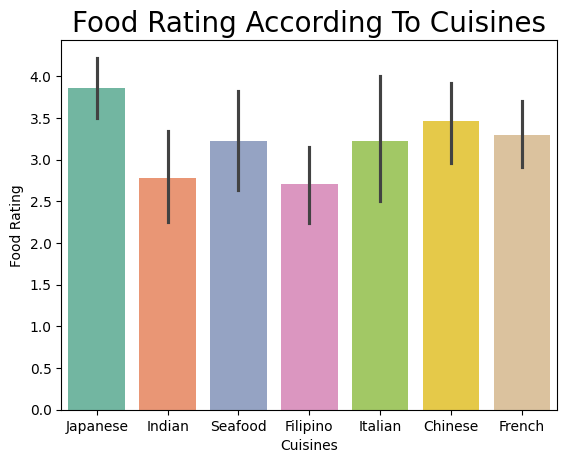

<Figure size 2000x1000 with 0 Axes>

In [12]:
sns.barplot(data=df, y="Food Rating",x='Cuisines',palette='Set2')
plt.title("Food Rating According To Cuisines",fontsize = 20)
plt.xlabel('Cuisines',fontsize=10)
plt.ylabel("Food Rating",fontsize=10)
fig = plt.figure(figsize=(20,10))
plt.show()

##### *Japanese,French,and Chinese cuisines have relatively high food ratings.Therefore the restaurant should consider focusing on or promoting on these higher-rated cuisines to attract customers.*

## **Pie chart representing budgets according to cuisines**

Text(0.5, 1.0, 'Budgets According To Cuisines')

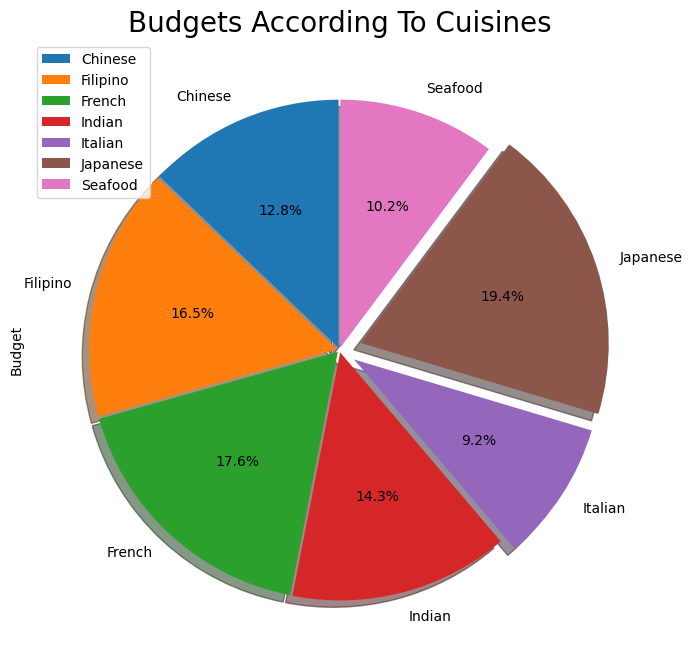

In [13]:
fig = plt.figure(figsize=(8,12))
cuisine_budget.plot(kind='pie',rot=90,explode=(0.01,0.01,0.01,0.01,0.07,0.09,0.01),startangle = 90,shadow = True,autopct='%1.1f%%', textprops={'fontsize': 10})
plt.legend()
plt.title("Budgets According To Cuisines",fontsize = 20)

##### *Allocating more budget to certain cuisines could mean promoting those more addressively.*

## **Ratings Breakdown:Food, Service & Overall**

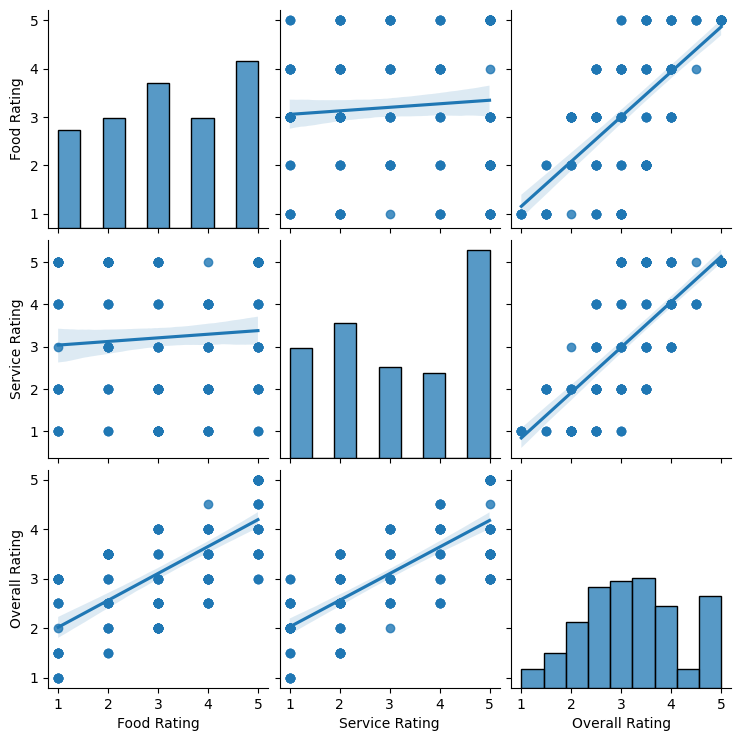

In [14]:
sns.pairplot(df,vars=['Food Rating','Service Rating','Overall Rating'], kind='reg')
plt.show()

## **Budget Distribution by Cuisine and Gender**

<Axes: xlabel='Cuisines', ylabel='Budget'>

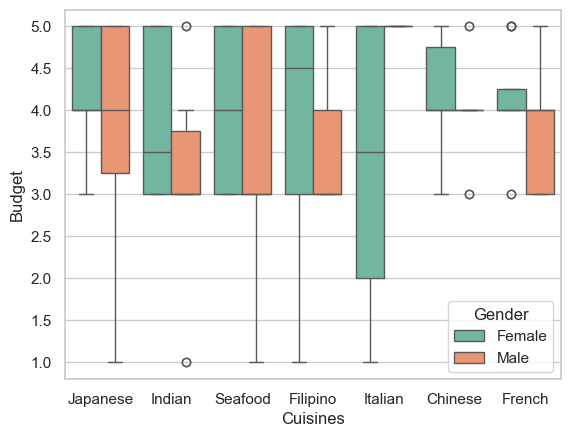

In [15]:
sns.set(style="whitegrid")
sns.boxplot(x="Cuisines", y="Budget",hue="Gender",data=df, palette="Set2",dodge=True)


##### *Here, for some cuisines like Indian,Chinese and Italian, Females seem to have a higher budget range compared to Males. In others like French and Japanese, Males have a higher budget range.There are outliers in cuisines like Japanese and Italian for Females.*

## **Correlation Analysis of User Data**

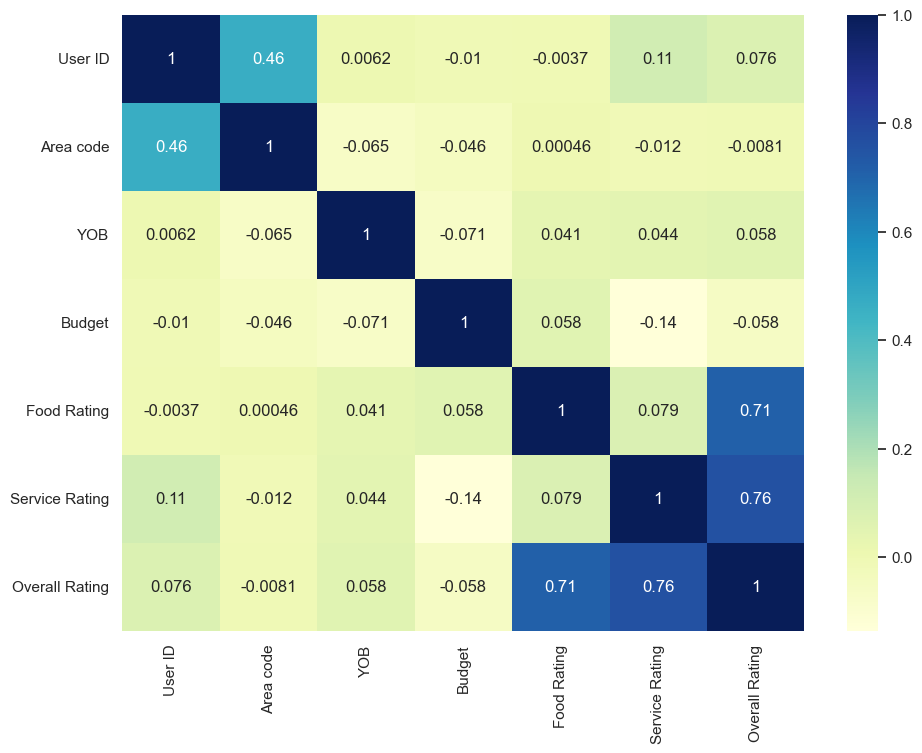

In [16]:
plt.figure(figsize = (11, 8))
df_numeric=df.select_dtypes(include='number')
cor=df_numeric.corr()
sns.heatmap(cor, annot = True, cmap="YlGnBu")
plt.show()

##### *There is a slight correlation between food rating , service rating and overall rating.These insights can help understand user behavior and preferences in relation to restaurant ratings and budgets.*